# 내 프로젝트 - 배터리 셀 검사 (완성 견본)

> ⭐ **실습 16부터 23까지를 한 노트북에 담은 완성본입니다.** 문제를 정하는 데서 시작해 저장소에 올릴 안내문까지 한 벌이 다 들어 있어요.
>
> **이것은 견본입니다.** 화면으로 함께 만든 것을 그대로 담았습니다.
> 여러분은 **본인 데이터로** 같은 순서를 한 벌 만드시면 됩니다. 이 파일은 고치지 말고 열어보기만 하세요.
>
> **막혔을 때 이 파일에서 그 단계만 찾아 보세요.** 아래 표에서 자리를 찾을 수 있습니다.

| 실습 | 이 노트북의 어디 |
|---|---|
| 실습 16 - 문제 정의서 | 문제 정의 · 쓰는 데이터 · 한계 |
| 실습 17 - 모델링 계획표 | 모델링 계획 |
| 실습 18 - 모델링 v1 | 문법 노트 · 내 갈래 · 코드 · 받은 코드 확인 |
| 실습 19 - 결과 한 장 | v1 결과 · 다음에 할 일 |
| 실습 22 - 결과 그림 세 장 | 중요 변수 · 혼동행렬 · 기준 모델과 견주기 |
| 실습 23 - 카드 여덟 칸 | 여덟 칸 · 지어낸 게 없는지 대조 |

> **결과물** — 그림 세 장은 `results` 폴더에, 저장소 안내문은 `README.md`로 나갑니다.

> 실습마다 맨 끝에 **도전** 칸이 하나씩 붙어 있습니다. 도전은 안 하셔도 되지만, **다 있으면 포트폴리오에 그대로 실립니다.**

# 실습 16 - 문제 정의서

## 문제 정의

**한 문장** : 배터리 셀 검사 측정값으로, 최종 검사 전에 불합격 가능성이 높은 셀을 먼저 골라낸다

| 물음 | 내 답 |
|---|---|
| 누가 쓰나 | 셀 검사 공정 담당자 |
| 무엇을 결정하나 | 이 셀을 정밀 재검사로 보낼지 말지 |
| 언제 결정하나 | 자동 측정이 끝나고 값이 표에 올라온 직후 |
| 이 판단이 늦으면 | 불합격 셀이 조립 공정까지 넘어가고, 완제품에서 발견되면 묶음 전체를 다시 봐야 한다 |

## 쓰는 데이터

| 항목 | 내용 |
|---|---|
| 출처 | 수업에서 받은 셀 검사 기록 |
| 규모 | 2847행 x 14열 |
| 입력으로 쓸 열 | 숫자로 된 측정 열 8개 |
| 결과 열 (TARGET) | result |
| 결과 열의 값 | 합격 / 불합격 |
| 문턱이 될 숫자 | 불합격 133건 (4.67%) |

## 한계

- 라인과 근무조가 표에 있지만 첫 판에서는 숫자 열만 썼다. 조별 차이는 아직 보지 않았다
- 기록 기간이 짧아 계절이나 원료 교체 같은 긴 흐름은 담기지 않았다
- 특정 측정값이 높은 구간에서 불합격이 많이 관찰되더라도, 그것이 원인이라고는 말할 수 없다

---

### 도전 - 말로 하는 30초 버전

배터리 셀은 검사에서 측정값이 열 개 넘게 나옵니다. 사람이 다 보기는 어려워서, 측정값만으로 불합격 가능성이 높은 셀을 먼저 골라내는 것을 만들었습니다. 셀 검사 담당자가 정밀 재검사로 보낼 셀을 고를 때 쓰는 것을 생각하고 만들었고, 전체의 4.67%만 불합격인 데이터라 정확도만 보면 안 되는 문제였습니다. 그래서 지목 건수와 그중 진짜였던 건수를 함께 봤습니다.

# 실습 17 - 모델링 계획표

## 모델링 계획

| # | 하는 일 | 내 경우엔 | 막힐 것 같나 |
|---|---|---|---|
| 1 | 파일 불러오기 | ../../data/day04_battery.csv | |
| 2 | 빈칸 채우기 | 숫자 열의 빈칸을 그 열의 중앙값으로 | |
| 3 | 결과 열을 숫자로 | result가 "불합격"이면 1, 아니면 0 | |
| 4 | 입력과 정답 나누기 | 입력은 측정 열 8개(features), 정답은 label | |
| 5 | 학습용·시험용 나누기 | 8대 2, 비율을 양쪽에 맞춰서 | |
| 6 | 기준 모델 점수 재기 | 전부 합격이라 답하는 모델 | |
| 7 | 모델 하나 학습시키기 | 표준화한 뒤 로지스틱 회귀 | 막힐 것 같음 |
| 8 | 결과 읽기 | 기준 모델과 나란히 놓고 비교 | 막힐 것 같음 |

### 이번 v1에서 볼 숫자

- 볼 숫자 : 기준 모델 정확도 / 내 모델 정확도 / 지목 건수 / 그중 진짜 / 정밀도 / 재현율
- 이걸 보는 이유 : 불합격이 4.67%라 전부 합격이라 답해도 95%가 넘는다. 정확도만 보면 잘한 걸로 착각한다

---

### 도전 - 입력에서 빼야 할 열이 있나 (데이터 누수 점검)

| 종류 | 있나 | 열 이름 | 어떻게 할까 |
|---|---|---|---|
| 번호·순번 열 | 있음 | cell_id | 글자로 되어 있어 숫자 열에 안 잡힌다. 그대로 두면 자동으로 빠진다 |
| 결과 뒤에 생기는 열 | 없음 | - | - |
| 결과 열의 사본 | 없음 | - | - |

- 확인한 것 : 숫자 열 8개는 모두 검사 장비에서 나온 측정값이고, 합격·불합격이 정해지기 전에 찍힌다
- 결론 : 입력 8개를 그대로 쓴다(DROP은 빈 목록). 다만 정확도가 99%를 넘으면 이 표를 다시 본다


# 실습 18 - 모델링 v1

## 모델링 v1

### 문법 노트 - 코드에서 찾을 이름

⭐ **오늘부터 변수 이름을 영어로 씁니다.** 이 코드가 그대로 GitHub 저장소에 올라가고 면접에서 열리기 때문입니다. 현업에서 쓰는 이름 그대로 익혀두면 남의 코드를 읽을 때도 바로 붙습니다.

| 이름 | 뜻 | 무엇이 들어 있나 |
|---|---|---|
| DATA_PATH | 데이터 파일 경로 | 내 csv 파일이 있는 자리 |
| TARGET | 맞히려는 열 | 결과 열 이름 |
| POSITIVE | 관심 갈래 | 그 열에서 찾으려는 쪽 (불합격·고장…) |
| features | 입력 열들 | 모델에 넣는 열 이름 목록 |
| DROP | 뺄 열 | 누수 점검에서 걸러낸 열 (없으면 빈 목록) |
| label | 정답표 | 찾으려는 쪽이면 1, 아니면 0 |
| X / y | 입력 / 정답 | 표 전체 입력값 / 0과 1 |
| X_train, X_test | 학습용 / 시험용 입력 | 8대 2로 나눈 것 |
| y_train, y_test | 학습용 / 시험용 정답 | 위와 짝 |
| baseline_pred | 기준 모델의 답안지 | 학습 없이 전부 0 |
| scaler | 같은 자로 맞추는 것 | StandardScaler |
| model | 학습시킨 모델 | LogisticRegression |
| y_pred | 모델이 내놓은 답 | 0과 1 |
| tp | true positive | 지목했는데 진짜였던 건수 |
| precision / recall | 정밀도 / 재현율 | 지난주에 이름 붙인 그 지표 |

| 쓴 함수 | 하는 일 |
|---|---|
| select_dtypes(include="number") | 숫자로 된 열만 골라낸다 |
| fillna(중앙값) | 빈칸을 그 열의 중앙값으로 채운다 |
| astype(int) | 참·거짓을 1과 0으로 바꾼다 |
| stratify=y | 나눌 때 비율을 양쪽에 맞춘다 |
| StandardScaler | 각 열을 같은 자로 재게 바꾼다 |
| max_iter=1000 | 계산을 끝까지 하게 한다 |

### 내 갈래

- 갈래 : A - 맞히기 (결과 열이 있다)
- 결과 열 : result / 관심 갈래 : 불합격
- 이 기준으로 정한 이유 : 현장에서 걸러내려는 게 불합격 셀이라서

In [3]:
import pandas as pd
import numpy as np

# 여기 세 줄만 내 것으로 바꾼다
DATA_PATH = "../../data/day04_battery.csv"   # 계획표 1번 줄에 적어둔 경로
TARGET    = "result"                     # 결과 열 이름 (target = 맞히려는 것)
POSITIVE  = "불합격"                      # 그 열에서 찾으려는 쪽 (positive = 관심 갈래)

df = pd.read_csv(DATA_PATH)

# 숫자로 된 열만 입력으로 쓴다. 결과 열은 답이므로 입력에서 뺀다
# features = 모델에 넣는 입력 열들
features = [c for c in df.select_dtypes(include="number").columns if c != TARGET]

# DROP - 도전(데이터 누수 점검)에서 찾은 빼야 할 열. 없으면 [] 그대로 둡니다
DROP = []
features = [c for c in features if c not in DROP]

# 빈칸을 그 열의 중앙값으로 채운다
df[features] = df[features].fillna(df[features].median())

# 판정을 숫자로 - 찾으려는 쪽이면 1, 아니면 0 (label = 정답표)
df["label"] = (df[TARGET] == POSITIVE).astype(int)

X = df[features]
y = df["label"]

print("표:", df.shape, "/ 입력으로 쓸 열:", len(features), "개")
print("찾으려는 쪽:", int(y.sum()), "건 (", round(y.mean() * 100, 2), "% )")

표: (2847, 15) / 입력으로 쓸 열: 8 개
찾으려는 쪽: 133 건 ( 4.67 % )


In [4]:
from sklearn.model_selection import train_test_split

# 8대 2로 나누되, 비율을 양쪽에 맞춰서
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y                 # 비율을 양쪽에 맞추라는 뜻
)

# baseline = 기준 모델. 학습하지 않고 전부 0(정상)이라 답하는 답안지
baseline_pred = np.zeros(len(y_test), dtype=int)
baseline_accuracy = (baseline_pred == y_test).mean()

print("학습용:", len(X_train), "건 (찾으려는 쪽", int(y_train.sum()), "건 )")
print("시험용:", len(X_test), "건 (찾으려는 쪽", int(y_test.sum()), "건 )")
print("기준 모델 정확도:", round(baseline_accuracy * 100, 2), "%")

학습용: 2277 건 (찾으려는 쪽 106 건 )
시험용: 570 건 (찾으려는 쪽 27 건 )
기준 모델 정확도: 95.26 %


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# scaler = 열마다 다른 단위를 같은 자로 맞춰주는 것
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # 기준은 학습용에서만 배운다
X_test_scaled  = scaler.transform(X_test)        # 시험용은 배운 기준을 적용만 한다

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)            # y_pred = 모델이 내놓은 답

accuracy  = (y_pred == y_test).mean()                          # 정확도
predicted = int((y_pred == 1).sum())                           # 지목한 건수
tp        = int(((y_pred == 1) & (y_test == 1)).sum())         # true positive - 지목했는데 진짜였던 것
precision = tp / predicted if predicted else 0                 # 정밀도
recall    = tp / int(y_test.sum())                             # 재현율

print("기준 모델 정확도:", round(baseline_accuracy * 100, 2), "%")
print("내 모델 정확도  :", round(accuracy * 100, 2), "%")
print("지목한 건수     :", predicted, "건")
print("그중 진짜       :", tp, "건")
print("시험용의 실제   :", int(y_test.sum()), "건")
print("정밀도 precision:", round(precision, 3))
print("재현율 recall   :", round(recall, 3))

기준 모델 정확도: 95.26 %
내 모델 정확도  : 97.02 %
지목한 건수     : 14 건
그중 진짜       : 12 건
시험용의 실제   : 27 건
정밀도 precision: 0.857
재현율 recall   : 0.444


### 받은 코드 확인

| # | 확인한 것 | 어땠나 |
|---|---|---|
| 1 | 비율 맞춰 나누기 (stratify) | 들어 있었다 |
| 2 | 표준화를 학습용에서만 (fit_transform / transform) | 시험용에도 fit 이 되어 있어 고쳐달라고 했다 |
| 3 | 기준 모델 | 없어서 넣어달라고 했다. 95.26%가 여기서 나왔다 |
| 4 | 지목 건수와 재현율 | 정확도만 있어서 추가로 요청했다 |

- 고친 것이 둘 : 시험용에 fit 하지 말라고 한 것, 기준 모델을 넣어달라고 한 것
- 둘 다 안 고쳤으면 97%만 보고 잘된 줄 알았을 것이다

---

### 도전 - 하이퍼파라미터를 바꿔본 결과

In [6]:
# class_weight - 드문 쪽을 무겁게 세라는 하이퍼파라미터
weighted_model = LogisticRegression(max_iter=1000, class_weight="balanced")
weighted_model.fit(X_train_scaled, y_train)
y_pred_weighted = weighted_model.predict(X_test_scaled)

tp_w = int(((y_pred_weighted == 1) & (y_test == 1)).sum())
print("[손 안 댐] 지목", int((y_pred == 1).sum()), "건 / 그중 진짜", tp, "건 / 재현율", round(recall, 3))
print("[가중치 ] 지목", int((y_pred_weighted == 1).sum()), "건 / 그중 진짜", tp_w, "건 / 재현율", round(tp_w / int(y_test.sum()), 3))

[손 안 댐] 지목 14 건 / 그중 진짜 12 건 / 재현율 0.444
[가중치 ] 지목 101 건 / 그중 진짜 25 건 / 재현율 0.926


| | 지목 | 그중 진짜 | 재현율 |
|---|---|---|---|
| 손 안 댐 | 14 | 12 | 0.444 |
| class_weight="balanced" | 101 | 25 | 0.926 |

- 알게 된 것 : 재현율이 0.444에서 0.926으로 올랐지만 헛걸음이 2건에서 76건으로 늘었다. 어느 쪽이 나은지는 재검사 한 건에 드는 비용을 알아야 정해진다

# 실습 19 - 결과 한 장

## v1 결과

| | 정확도 | 지목 | 그중 진짜 | 정밀도 | 재현율 |
|---|---|---|---|---|---|
| 기준 모델 (전부 합격) | 95.26% | 0건 | 0건 | - | 0.000 |
| 내 모델 v1 | 97.02% | 14건 | 12건 | 0.857 | 0.444 |

- 시험용에 실제로 있던 불합격 : 27건
- 한 줄 요약 : 정확도는 기준보다 1.76%p 올랐고 지목한 14건 중 12건이 실제 불합격이었다(정밀도 0.857). 다만 실제 27건 중 15건은 못 잡았다(재현율 0.444)

### 다음에 할 일

1. class_weight로 드문 쪽을 무겁게 세어 재현율을 올려보기 (실습 18 도전에서 한 번 돌려봤다 - 헛걸음이 크게 늘었다)
2. 재현율이 오를 때 헛걸음이 얼마나 느는지 같이 재기
3. 재검사 한 건에 드는 비용을 알아보고, 어느 쪽이 나은지 정하기

### 카드에 옮겨 적을 것

**3번 칸 - 사용 데이터**
셀 검사 기록 / 2847행 x 14열 / 결과 열은 합격·불합격 / 불합격 133건 (4.67%)

**5번 칸 - 결과 수치**
전부 합격이라 답하는 기준 모델 95.26% 대비 97.02%.
지목한 14건 중 12건이 실제 불합격이었으나(정밀도 0.857),
실제 27건 중 15건은 못 잡았다(재현율 0.444). 그래서 정확도만으로는 판단할 수 없는 문제였다

---

### 도전 - 그래서 무엇을 하자는 것인가

- 측정값이 이 조건에 걸리는 셀은 최종 검사 전에 정밀 재검사 대상으로 따로 빼두자는 것. 다만 지금 v1로는 실제 27건 중 12건만 걸러지므로, 이 상태로 현장에 거는 것은 이르다

# 실습 22 - 결과 그림 세 장

출력 창은 만든 사람만 읽습니다. 남이 30초 안에 읽을 수 있게 **세 장**으로 만들어 파일로 남깁니다.

| 그림 | 무엇을 보여주나 | 파일 이름 |
|---|---|---|
| 1 | 무엇을 보고 판단했나 | results/fig1_importance.png |
| 2 | 어떻게 틀렸나 | results/fig2_confusion.png |
| 3 | 아무것도 안 했을 때보다 나은가 | results/fig3_compare.png |

## Step 1. 그림 1 - 무엇을 보고 판단했나

### 문법 노트 - 이 그림의 이름

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| 중요 변수 (feature importance) | 어느 열이 판단에 많이 쓰였는지 보여주는 그림 | 카드 6번 칸과 면접에서 이 이름으로 부른다 |
| model.coef_ | 모델이 각 열에 매긴 무게 | 크기가 클수록 많이 쓰였다는 뜻 |
| np.abs | 부호를 떼고 크기만 본다 | 올리는 쪽이든 내리는 쪽이든 "많이 썼다"는 같다 |
| barh | 가로 막대 | 열 이름이 길어도 글자가 안 겹친다 |

⚠️ 이 그림은 **원인이 아니다.** "이 항목이 불합격을 일으킨다"가 아니라 "모델이 이 항목을 많이 봤다"이다.

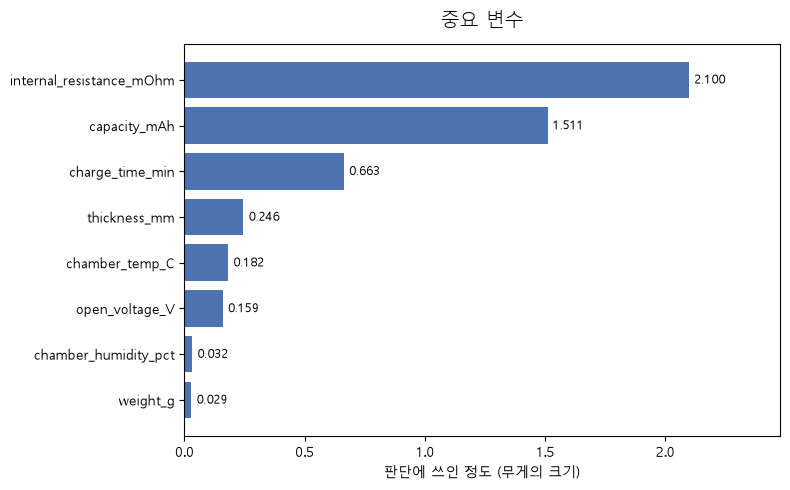

In [7]:
import matplotlib.pyplot as plt
import platform, os

# 한글이 깨지지 않게 폰트를 먼저 잡는다 (윈도우와 맥이 서로 다르다)
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 뜨는 것을 막는다

# 그림을 담을 폴더를 만든다 (이미 있으면 그냥 둔다)
os.makedirs("results", exist_ok=True)

# 열마다 매겨진 무게의 크기를 구해 큰 것부터 10개만 본다
importance = pd.Series(np.abs(model.coef_[0]), index=features)
importance = importance.sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance.index, importance.values, color="#4C72B0")

# 막대 옆에 값을 적는다 - 눈대중이 아니라 숫자로 읽히게
for bar, value in zip(bars, importance.values):
    ax.text(value + importance.max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:.3f}", va="center", fontsize=9)

ax.set_title("중요 변수", fontsize=14, pad=12)
ax.set_xlabel("판단에 쓰인 정도 (무게의 크기)")
ax.set_xlim(0, importance.max() * 1.18)
fig.tight_layout()
fig.savefig("results/fig1_importance.png", dpi=150)   # 화면에만 띄우지 않고 파일로 남긴다
plt.show()

30초 동안 본 것

- 막대가 가장 긴 것은 **내부저항**(internal_resistance_mOhm, 2.100), 그다음이 **용량**(capacity_mAh, 1.511)
- 검사에서 실제로 눈여겨보는 두 값이라 납득이 된다
- 무게(weight_g)와 습도(chamber_humidity_pct)는 거의 0이다. 이 판단에는 쓰이지 않았다

## Step 2. 그림 2 - 어떻게 틀렸나

3일차에 손으로 만들어 본 그 네 칸입니다. 이름이 **혼동행렬**이었죠. 오늘은 그림으로 만들어 파일로 남깁니다.

### 문법 노트 - 네 칸의 이름

| 칸 | 우리말 | 이 데이터에서 |
|---|---|---|
| TN | 맞게 합격이라 한 것 | 541건 |
| FP | 헛경보 (합격인데 불합격이라 함) | 2건 |
| FN | 놓친 것 (불합격인데 합격이라 함) | 15건 |
| TP | 제대로 잡은 것 | 12건 |

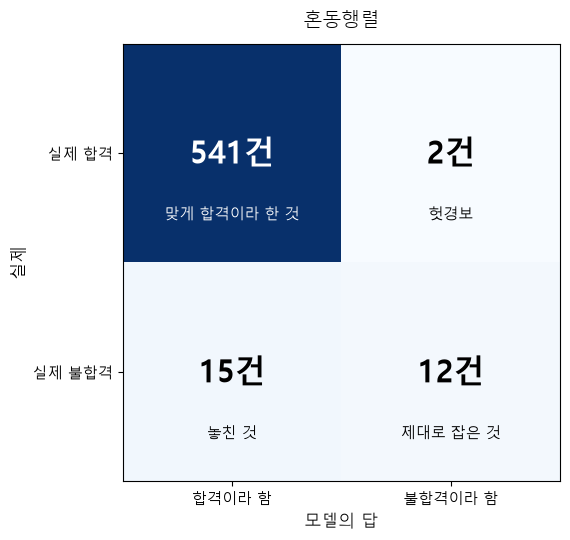

In [8]:
# 네 칸을 직접 센다 - 어느 칸이 무엇인지 눈으로 보이게
tn = int(((y_pred == 0) & (y_test == 0)).sum())   # 맞게 합격이라 한 것
fp = int(((y_pred == 1) & (y_test == 0)).sum())   # 헛경보
fn = int(((y_pred == 0) & (y_test == 1)).sum())   # 놓친 것
tp = int(((y_pred == 1) & (y_test == 1)).sum())   # 제대로 잡은 것

matrix = np.array([[tn, fp], [fn, tp]])
names  = [["맞게 합격이라 한 것", "헛경보"], ["놓친 것", "제대로 잡은 것"]]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())

# 칸마다 건수를 크게, 그 아래에 무슨 뜻인지 한국어로
for i in range(2):
    for j in range(2):
        color = "white" if matrix[i, j] > matrix.max() * 0.5 else "black"
        ax.text(j, i, f"{matrix[i, j]}건", ha="center", va="center",
                fontsize=22, color=color, fontweight="bold")
        ax.text(j, i + 0.28, names[i][j], ha="center", va="center",
                fontsize=11, color=color)

ax.set_xticks([0, 1]); ax.set_xticklabels(["합격이라 함", "불합격이라 함"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 합격", "실제 불합격"], fontsize=11)
ax.set_xlabel("모델의 답", fontsize=12)
ax.set_ylabel("실제", fontsize=12)
ax.set_title("혼동행렬", fontsize=14, pad=12)
fig.tight_layout()
fig.savefig("results/fig2_confusion.png", dpi=150)
plt.show()

두 칸을 짚어본 것

- **놓친 것 15건** - 실제 불합격 27건 중 절반이 넘는다
- **헛경보 2건** - 지목한 14건 중 2건만 헛걸음이었다

지목은 정확했지만 **너무 조금 지목했다.** 이 둘의 값이 다르다는 게 카드 5번 칸에 들어갈 이야기입니다.

## Step 3. 그림 3 - 기준 모델보다 나은가

⭐ 기준 모델 막대가 이 세 장에서 제일 중요합니다. 내 점수만 있으면 보는 사람이 좋은 건지 나쁜 건지 모릅니다.

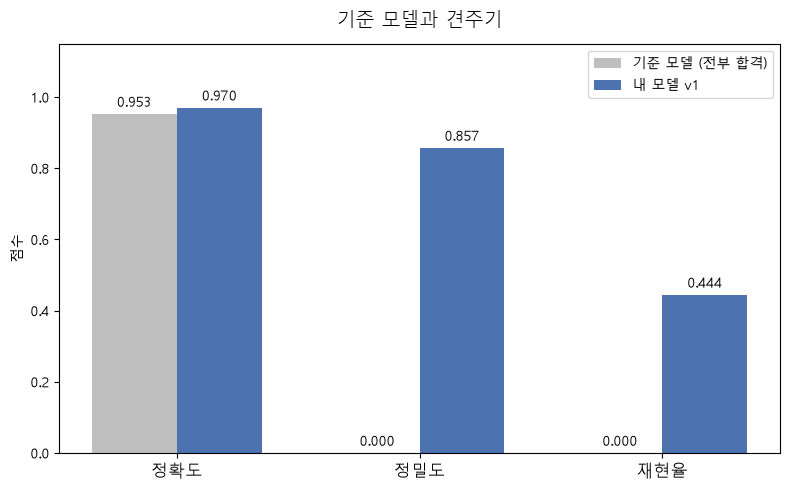

In [9]:
labels   = ["정확도", "정밀도", "재현율"]
baseline = [baseline_accuracy, 0.0, 0.0]   # 하나도 지목하지 않으므로 정밀도·재현율은 0
mine     = [accuracy, precision, recall]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_base = ax.bar(x - width / 2, baseline, width, label="기준 모델 (전부 합격)", color="#BFBFBF")
bars_mine = ax.bar(x + width / 2, mine,     width, label="내 모델 v1",           color="#4C72B0")

# 막대 위에 값을 적는다
for bars in (bars_base, bars_mine):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha="center", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("점수")
ax.set_title("기준 모델과 견주기", fontsize=14, pad=12)
ax.legend()
fig.tight_layout()
fig.savefig("results/fig3_compare.png", dpi=150)
plt.show()

이 그림이 말하는 것

정확도 막대만 보면 0.953과 0.970으로 **거의 같아 보입니다.** 그런데 정밀도와 재현율에서는 기준 모델이 **0**입니다.

전부 합격이라 답하면 95%를 맞히지만 불합격은 **한 건도** 못 잡기 때문입니다. 정확도 하나만 들고 가면 안 되는 이유가 이 그림에 다 있습니다.

## Step 4. 세 장이 증명하는 것

1. 중요 변수 : 내부저항(2.100)과 용량(1.511)이 가장 많이 쓰였다. 원인이라는 뜻은 아니다
2. 혼동행렬 : 지목 14건 중 12건이 진짜였고 헛경보는 2건, 실제 27건 중 15건은 놓쳤다
3. 기준 모델과 견주기 : 정확도는 95.26%와 97.02%로 비슷하지만, 기준 모델은 정밀도·재현율이 0이라 하나도 못 잡는다는 점이 다르다

⭐ 이 세 줄이 카드 6번 칸의 캡션이 됩니다.

---
## 직접 해보기 (도전) - 기준을 옮기면 무엇이 달라지나

- 상황: 놓친 것을 줄이자니 헛경보가 늘 것 같다
- 할 일: 문턱을 낮춰 혼동행렬을 한 번 더 그리고, 두 장을 나란히 놓는다
- 결과물: 그림 파일 fig4_threshold.png 1개 + 네 숫자 비교표 1개

### 문법 노트 - 문턱을 옮긴다는 것

**모델은 사실 "불합격이다 / 아니다"가 아니라 확률을 갖고 있다.** 3일차에 표로 본 그것이다. 오늘은 그걸 코드로 만진다.

같은 셀 다섯 개를 두 문턱으로 판정하면 이렇게 갈린다.

| 불합격일 확률 | 문턱 0.50 | 문턱 0.05 |
|---|---|---|
| 0.80 | 불합격 | 불합격 |
| 0.60 | 불합격 | 불합격 |
| **0.30** | 합격 | **불합격** |
| **0.10** | 합격 | **불합격** |
| 0.03 | 합격 | 합격 |

가운데 두 줄이 뒤집힌다. **모델은 그대로인데 판정만 바뀐 것.**

아래 코드의 이 한 줄이 그 일을 한다 - `pred = (proba >= line)`

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| `predict_proba` | 0·1 대신 **확률**을 돌려준다 | 문턱을 내가 정하려면 확률이 있어야 한다 |
| `proba` | 불합격일 확률 (0에서 1 사이) | 이 값을 문턱과 견준다 |
| `line` | **문턱** - 내가 정하는 경계 | 0.50과 0.05 두 가지로 돌려본다 |
| `>=` | 확률이 문턱 **이상이면 1**(불합격) | 미만이면 0(합격) |

⭐ **다섯 날 동안 쓴 `predict` 가 사실 이걸 하고 있었다** - 확률을 **0.50에서 자르기**. 문턱이 0.50으로 고정돼 있었을 뿐이다.

- **문턱을 낮추면** : 의심스러운 것까지 넓게 잡는다 → 놓침 ↓ · 헛경보 ↑
- **문턱을 높이면** : 확실한 것만 잡는다 → 놓침 ↑ · 헛경보 ↓

**정식 이름은 판정 임계값(threshold).** 아래에서 만들 그림 파일 이름에도 그 단어가 들어간다.

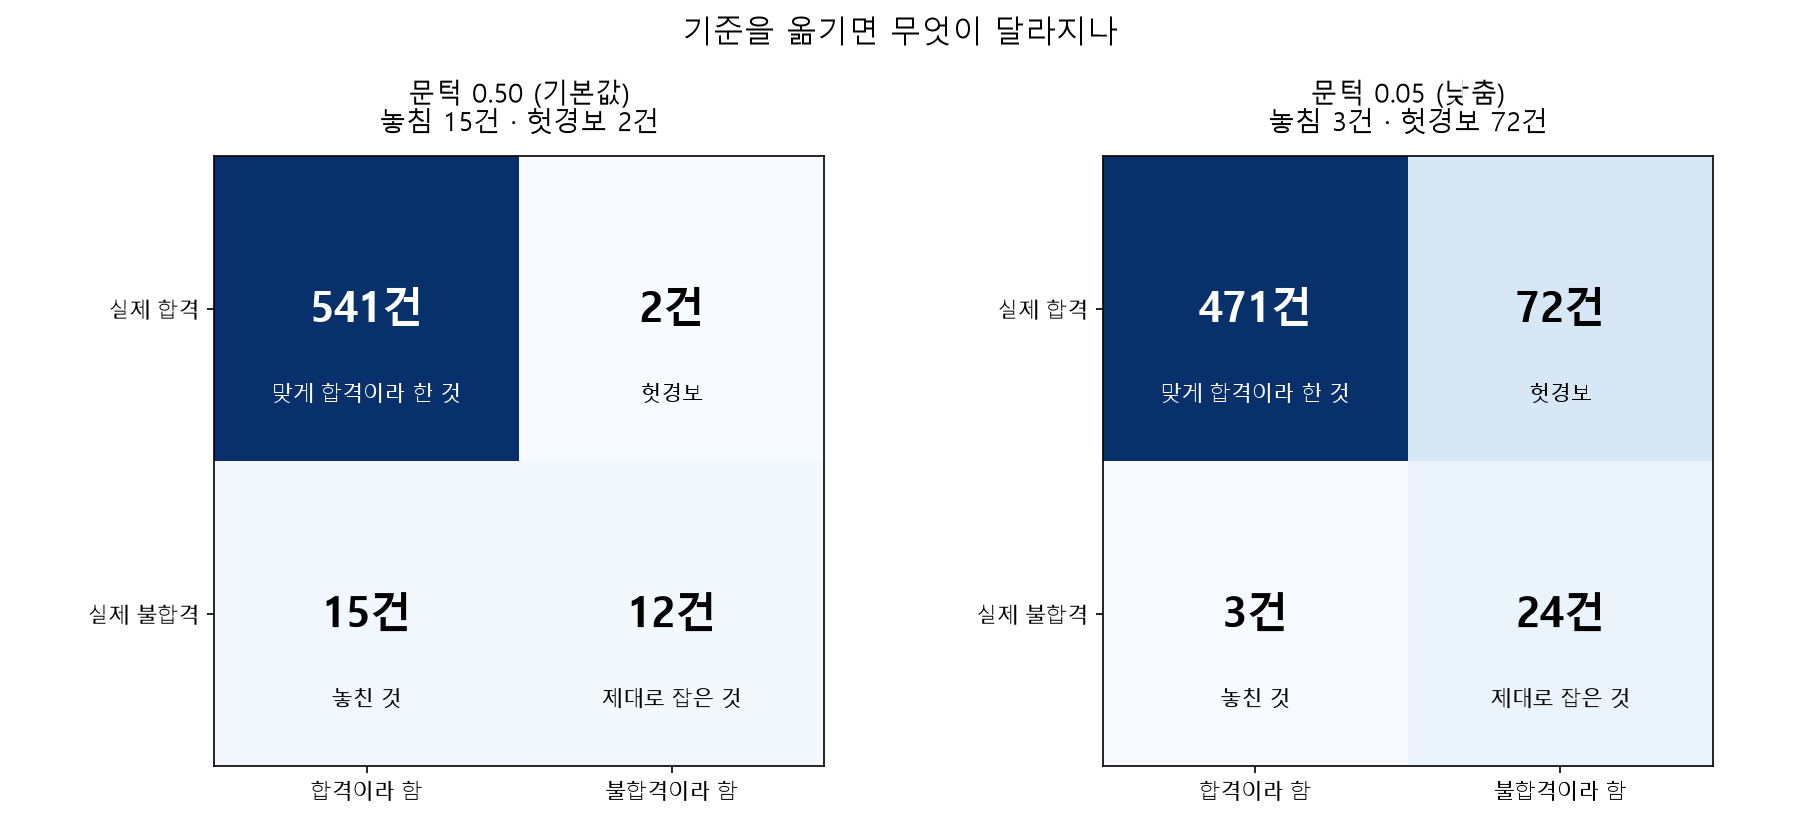

              문턱 0.50    문턱 0.05
지목                 14             96
그중 진짜            12             24
헛경보                2             72
놓침                 15              3


In [ ]:
# 0과 1 대신 확률을 받는다 - 두 번째 열이 불합격일 확률
proba = model.predict_proba(X_test_scaled)[:, 1]

names = [["맞게 합격이라 한 것", "헛경보"], ["놓친 것", "제대로 잡은 것"]]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, line in zip(axes, [0.50, 0.05]):
    pred = (proba >= line).astype(int)          # 내가 정한 선으로 자른다
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    tp = int(((pred == 1) & (y_test == 1)).sum())
    matrix = np.array([[tn, fp], [fn, tp]])

    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
    for i in range(2):
        for j in range(2):
            color = "white" if matrix[i, j] > matrix.max() * 0.5 else "black"
            ax.text(j, i, f"{matrix[i, j]}건", ha="center", va="center",
                    fontsize=20, color=color, fontweight="bold")
            ax.text(j, i + 0.28, names[i][j], ha="center", va="center",
                    fontsize=10, color=color)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["합격이라 함", "불합격이라 함"], fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 합격", "실제 불합격"], fontsize=10)
    label = "기본값" if line == 0.50 else "낮춤"
    ax.set_title(f"문턱 {line:.2f} ({label})\n놓침 {fn}건 · 헛경보 {fp}건", fontsize=13, pad=12)

fig.suptitle("기준을 옮기면 무엇이 달라지나", fontsize=15)
fig.tight_layout()
fig.savefig("results/fig4_threshold.png", dpi=150)
plt.show()

# 네 숫자를 표로 다시 센다
print("              문턱 0.50    문턱 0.05")
rows = {}
for line in [0.50, 0.05]:
    pred = (proba >= line).astype(int)
    tp = int(((pred == 1) & (y_test == 1)).sum())
    fp = int((pred == 1).sum()) - tp
    rows[line] = [tp + fp, tp, fp, int(y_test.sum()) - tp]
for name, i in [("지목", 0), ("그중 진짜", 1), ("헛경보", 2), ("놓침", 3)]:
    print(f"{name:<12}{rows[0.50][i]:>10}{rows[0.05][i]:>15}")

읽은 것

- **놓침이 15건에서 3건으로** 줄었다. 실제 불합격 27건 중 24건을 잡았다
- 대신 **헛경보가 2건에서 72건으로** 늘었다. 지목 96건 중 72건이 헛걸음이다
- ⭐ **어느 쪽이 맞는지는 이 그림이 안 알려준다.** 재검사 한 건 값과 놓친 한 건 값을 알아야 정해진다

카드 7번 칸에 이렇게 적었다 — *"놓친 불합격 한 건이 재검사 한 건보다 비싼 공정이라면 문턱을 낮추는 편이 낫다"*

# 실습 23 - 카드 여덟 칸

## Step 1. 여덟 칸 채우기

**1. 제목 + 한 줄 요약**

배터리 셀 검사 측정값으로 불합격 셀 미리 골라내기 - 측정 열 8개로 최종 검사 전에 정밀 재검사 대상을 추린다

**2. 왜 이 문제인가**

불합격 셀이 조립 공정까지 넘어가면 완제품에서 발견되어 묶음 전체를 다시 봐야 한다. 검사 단계에서 거르는 것과 조립 뒤에 아는 것은 비용이 다르다

**3. 사용 데이터**

셀 검사 기록 / 2,847행 x 14열 / 결과 열은 합격·불합격 / 불합격 133건 (4.67%)

**4. 무엇을 했나**

숫자 측정 열 8개를 입력으로 씀 / 빈칸은 그 열의 중앙값으로 채움 / 8대 2로 비율을 맞춰 나눔 / 표준화 후 분류 모델을 학습시키고, 전부 합격이라 답하는 기준 모델과 견줌

**5. 결과 수치**

전부 합격이라 답하는 기준 모델 95.26% 대비 97.02%. 지목한 14건 중 12건이 실제 불합격이었으나(정밀도 0.857), 실제 27건 중 15건은 놓쳤다(재현율 0.444). 정확도 차이가 1.76%p뿐이라 정확도만으로는 판단할 수 없는 문제였다

**6. 결과 그림**

중요 변수 / 혼동행렬 / 기준 모델과 견주기 - 세 장 (results 폴더)

**7. 의사결정 가치**

측정값이 이 조건에 걸리는 셀을 최종 검사 전에 정밀 재검사 대상으로 빼두자는 것. 헛걸음 한 건보다 놓친 불합격 한 건이 비싼 공정이라면 문턱을 낮춰 지목을 늘리는 편이 낫다

**8. 한계와 다음**

라인과 근무조가 표에 있지만 첫 판에서는 숫자 열만 썼다. 기록 기간이 짧아 원료 교체 같은 긴 흐름은 담기지 않았다. 내부저항이 높은 구간에 불합격이 몰려 있었으나 그것이 원인이라고 말할 수는 없다. 다음에 고칠 것 두 가지 — 빈칸을 나누기 전에 전체 중앙값으로 채웠으니 학습용 기준으로 바꾸고, 드문 쪽을 무겁게 세었을 때 늘어나는 헛걸음(2건에서 76건)의 비용을 알아보고 어느 쪽이 나은지 정할 것

## Step 2. 지어낸 게 없는지 대조하기

여덟 칸의 숫자와 이름을 하나씩 노트북 화면에서 찾아 확인했습니다.

| 확인할 것 | 어디서 찾았나 | 맞나 |
|---|---|---|
| 3번의 2,847행 x 14열 · 4.67% | 실습 18 첫 코드 칸 출력 | 확인 |
| 5번의 95.26% / 97.02% | 실습 18 마지막 코드 칸 출력 | 확인 |
| 5번의 지목 14 / 진짜 12 / 실제 27 | 실습 18 마지막 코드 칸 출력 | 확인 |
| 6번의 그림 이름 세 개 | results 폴더 | 확인 |
| 8번의 2건에서 76건 | 실습 18 도전 표 (헛걸음 = 지목 - 진짜) | 확인 |

⭐ 화면에서 못 찾은 숫자는 없습니다. 하나라도 못 찾았으면 그 숫자는 지웁니다.

---
## 직접 해보기 (도전) - 주소 하나로 통째로 받아오기

- 상황: 올리는 건 해봤는데, 받아오는 건 아직 안 해봤다
- 할 일: 강사 저장소를 주소로 받아와 폴더를 열어본다
- 결과물: 받아온 폴더 1개 + 그 안의 노트북 개수

받아온 것

받아온 폴더 이름 : secom-project-teacher
그 안의 노트북 개수 : 15개

열어보니 `day01` 부터 날짜별 폴더가 있고, 그 안에 `labNN_이름` 폴더가 실습마다 하나씩 들어 있었다. **내가 다섯 날 동안 만든 것과 같은 모양**이다.

⭐ 주소 한 줄로 남의 작업 전체가 통째로 들어온다. 파일을 하나씩 받는 게 아니다.

⚠️ 내 저장소 **바깥에** 받아야 한다. 안에 받으면 내 것에 딸려 올라간다.